In [1]:
# ── CELL 1: Imports ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── CELL 2: Load all three sheets ─────────────────────────────
FILE = "F:/Semester 5/Data Visualization & Story telling/ASSIGNMENT  2/SDG14_Marine_Pollution/Data/JMP_WASH_HH_2025_by_country-2.xlsx"

wat = pd.read_excel(FILE, sheet_name='wat', header=0)
san = pd.read_excel(FILE, sheet_name='san', header=0)
hyg = pd.read_excel(FILE, sheet_name='hyg', header=0)

print(f"Water      : {wat['name'].nunique()} countries | "
      f"{wat['year'].min()}–{wat['year'].max()} | {len(wat)} rows")
print(f"Sanitation : {san['name'].nunique()} countries | "
      f"{san['year'].min()}–{san['year'].max()} | {len(san)} rows")
print(f"Hygiene    : {hyg['name'].nunique()} countries | "
      f"{hyg['year'].min()}–{hyg['year'].max()} | {len(hyg)} rows")

Water      : 233 countries | 2000–2024 | 5678 rows
Sanitation : 234 countries | 2000–2024 | 5668 rows
Hygiene    : 196 countries | 2000–2024 | 3714 rows


In [3]:
# ── CELL 3: Build master merged dataset ───────────────────────
# Column key:
#   _t = total/national   _r = rural   _u = urban
#   arc_ = annual rate of change

wat_cols = ['name','iso3','year','pop_t','prop_u',
            'wat_basal_t','wat_lim_t','wat_unimp_t','wat_ns_t',
            'wat_basal_r','wat_basal_u',
            'arc_wat_basal_t',
            'region_income','region_sdg',
            'region_ldc','region_sids','region_lldc']

san_cols = ['name','iso3','year',
            'san_basal_t','san_lim_t','san_unimp_t','san_ns_t',
            'san_basal_r','san_basal_u',
            'arc_san_basal_t']

hyg_cols = ['name','iso3','year',
            'hyg_bas_t','hyg_lim_t','hyg_ns_t',
            'hyg_bas_r','hyg_bas_u',
            'arc_hyg_bas_t']

# Merge water + sanitation first (same 233/234 countries)
df = wat[wat_cols].merge(san[san_cols], on=['name','iso3','year'], how='inner')

# Left-join hygiene so we keep all countries (NaN where hygiene absent)
df = df.merge(hyg[hyg_cols], on=['name','iso3','year'], how='left')

# Clean income labels
df['region_income'] = df['region_income'].fillna('Unknown')

print(f"Master dataset: {df.shape[0]} rows | {df['name'].nunique()} countries")
print(f"Years: {df['year'].min()}–{df['year'].max()}")
print(f"\nMissing values in core columns:")
core = ['wat_basal_t','san_basal_t','hyg_bas_t']
print(df[df['year']==2024][core].isna().sum())

Master dataset: 5594 rows | 233 countries
Years: 2000–2024

Missing values in core columns:
wat_basal_t      3
san_basal_t      4
hyg_bas_t      123
dtype: int64


In [4]:
# ── CELL 4: Confirm Sri Lanka ──────────────────────────────────
sl = df[df['name'] == 'Sri Lanka'].copy()

print(f"Sri Lanka rows  : {len(sl)}")
print(f"Income group    : {sl['region_income'].iloc[0]}")
print(f"SDG region      : {sl['region_sdg'].iloc[0]}")
print(f"LDC status      : {sl['region_ldc'].iloc[0]}")
print()

display_cols = ['year','wat_basal_t','san_basal_t','hyg_bas_t']
print("Sri Lanka WASH values (selected years):")
print(sl[sl['year'].isin([2000,2005,2010,2015,2020,2024])][display_cols].to_string(index=False))

Sri Lanka rows  : 25
Income group    : Lower middle income
SDG region      : Central and Southern Asia
LDC status      : nan

Sri Lanka WASH values (selected years):
 year  wat_basal_t  san_basal_t  hyg_bas_t
 2000    83.675066    76.807267        NaN
 2005    85.033028    80.822545        NaN
 2010    86.429156    84.916654        NaN
 2015    87.843048    89.089772  87.612359
 2020    89.302480    93.346318  87.644662
 2024    90.213844    95.353021  87.694348


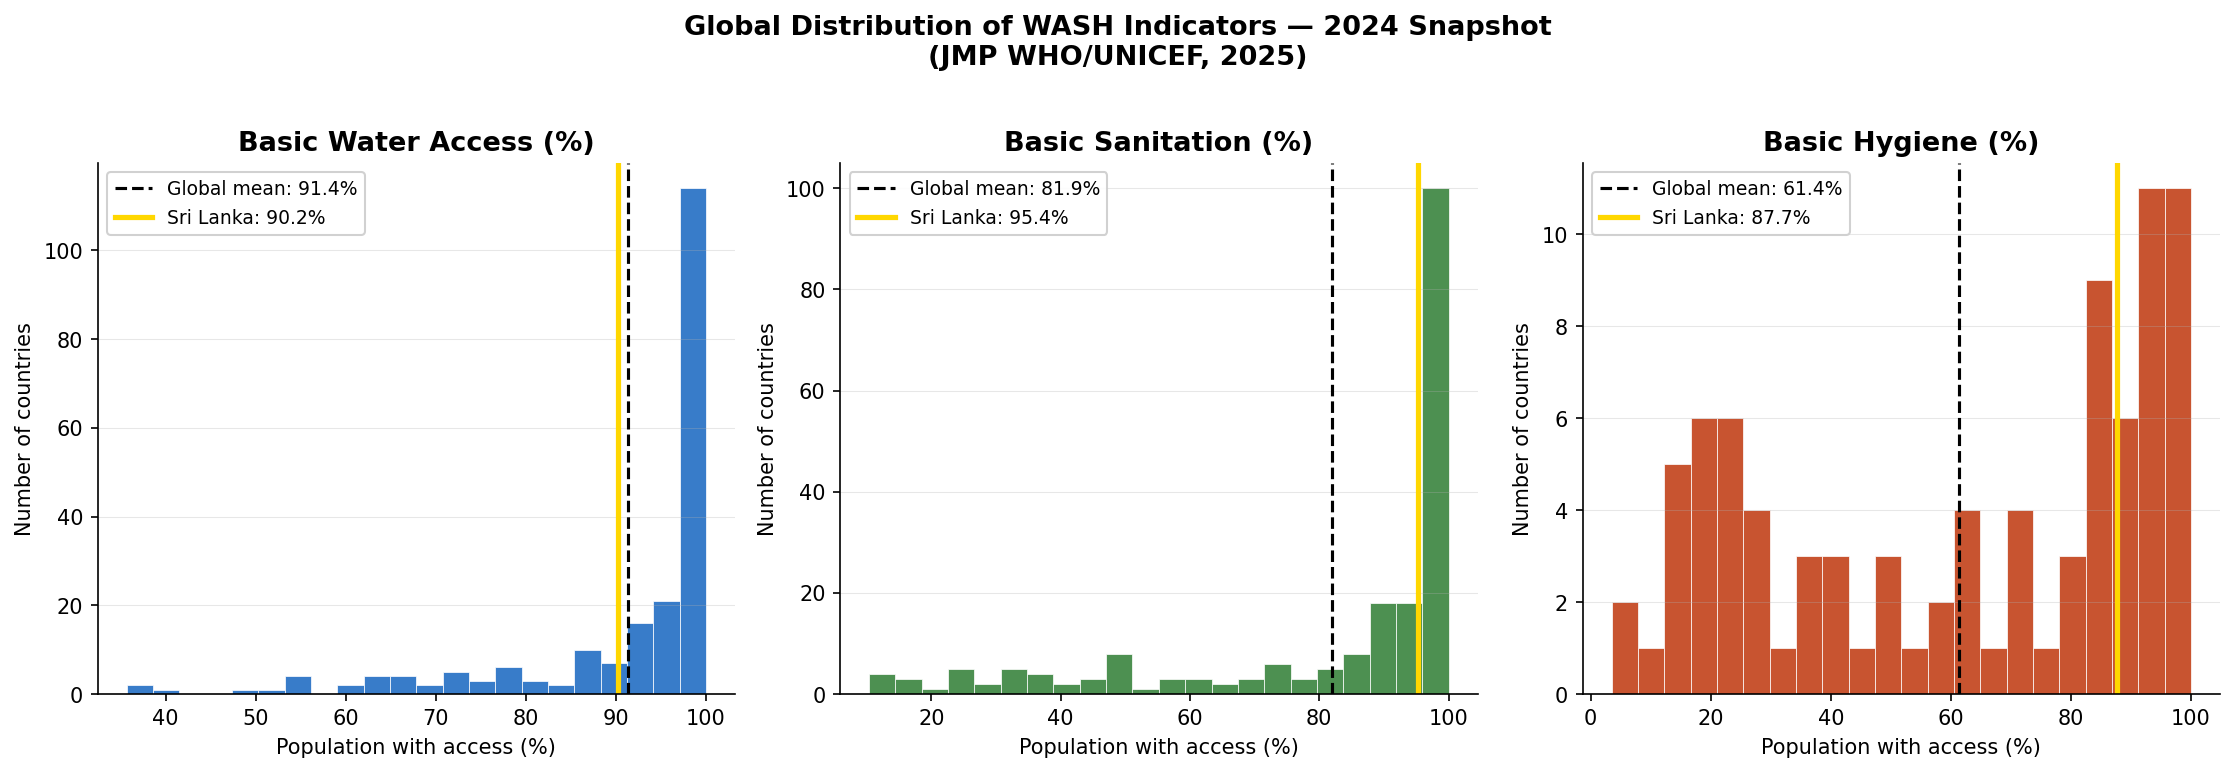

Saved: figures/fig1_wash_distributions.png


In [5]:
# ── CELL 5: Figure 1 — Global WASH distributions (2024) ───────
df2024 = df[df['year'] == 2024].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Global Distribution of WASH Indicators — 2024 Snapshot\n'
             '(JMP WHO/UNICEF, 2025)', fontsize=13, fontweight='bold', y=1.02)

configs = [
    ('wat_basal_t', 'Basic Water Access (%)',   '#1565C0'),
    ('san_basal_t', 'Basic Sanitation (%)',     '#2E7D32'),
    ('hyg_bas_t',   'Basic Hygiene (%)',         '#BF360C'),
]

for ax, (col, title, color) in zip(axes, configs):
    data = df2024[col].dropna()
    ax.hist(data, bins=22, color=color, edgecolor='white', alpha=0.85, linewidth=0.4)

    mean_val = data.mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5,
               label=f'Global mean: {mean_val:.1f}%')

    # Highlight Sri Lanka
    sl_val = sl[sl['year'] == 2024][col].values
    if len(sl_val) > 0 and not np.isnan(sl_val[0]):
        ax.axvline(sl_val[0], color='gold', linestyle='-', linewidth=2.5,
                   label=f'Sri Lanka: {sl_val[0]:.1f}%')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Population with access (%)')
    ax.set_ylabel('Number of countries')
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig1_wash_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig1_wash_distributions.png")

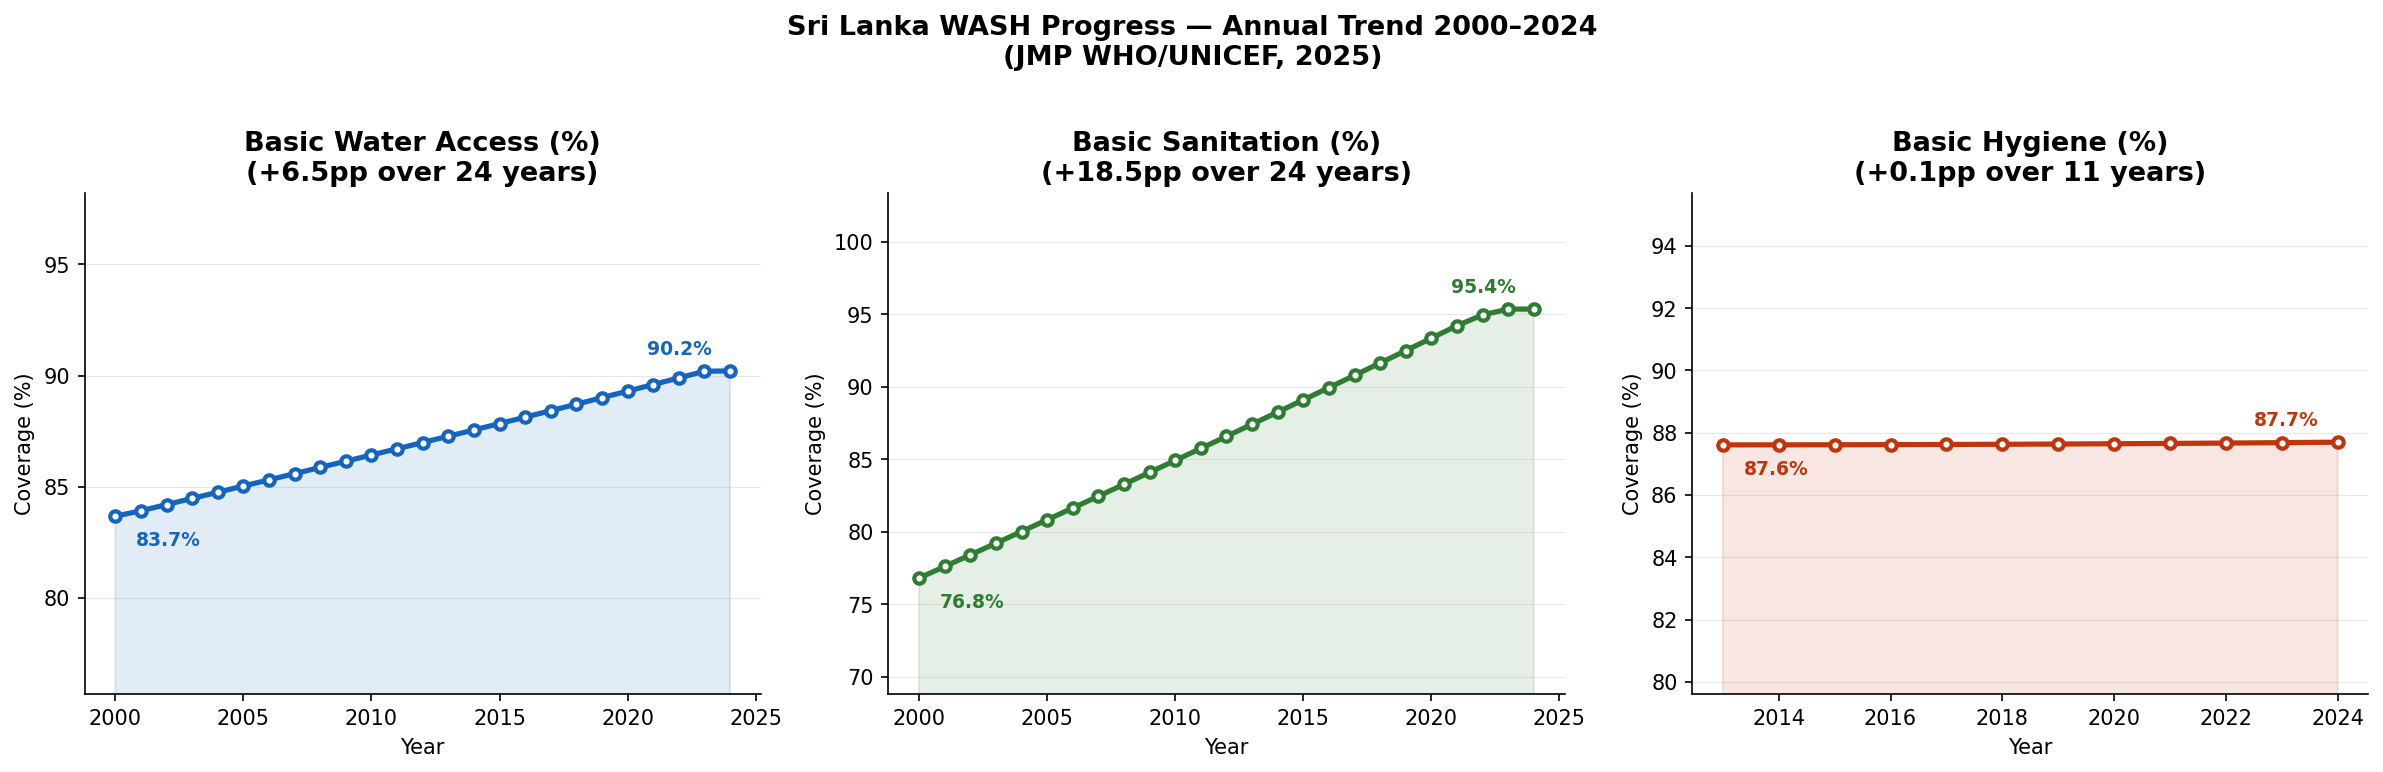

Saved: figures/fig2_srilanka_trend.png


In [6]:
# ── CELL 6: Figure 2 — Sri Lanka 25-year annual trend ─────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sri Lanka WASH Progress — Annual Trend 2000–2024\n'
             '(JMP WHO/UNICEF, 2025)', fontsize=13, fontweight='bold', y=1.02)

trend_configs = [
    ('wat_basal_t', 'Basic Water Access (%)',   '#1565C0', 2000),
    ('san_basal_t', 'Basic Sanitation (%)',     '#2E7D32', 2000),
    ('hyg_bas_t',   'Basic Hygiene (%)',         '#BF360C', 2013),
]

for ax, (col, title, color, start_yr) in zip(axes, trend_configs):
    sl_data = sl[sl['year'] >= start_yr].dropna(subset=[col]).sort_values('year')
    yrs  = sl_data['year'].values
    vals = sl_data[col].values

    # Fill area under line
    ax.fill_between(yrs, vals, alpha=0.12, color=color)
    ax.plot(yrs, vals, 'o-', color=color, linewidth=2.5,
            markersize=5, markerfacecolor='white',
            markeredgewidth=2, zorder=3, label='Sri Lanka')

    # Annotate start and end
    ax.annotate(f'{vals[0]:.1f}%', (yrs[0], vals[0]),
                xytext=(10, -14), textcoords='offset points',
                fontsize=9, fontweight='bold', color=color)
    ax.annotate(f'{vals[-1]:.1f}%', (yrs[-1], vals[-1]),
                xytext=(-40, 8), textcoords='offset points',
                fontsize=9, fontweight='bold', color=color)

    improvement = vals[-1] - vals[0]
    span = yrs[-1] - yrs[0]
    ax.set_title(f'{title}\n(+{improvement:.1f}pp over {span} years)', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Coverage (%)')
    ax.set_ylim(max(0, vals.min() - 8), min(105, vals.max() + 8))
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig2_srilanka_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig2_srilanka_trend.png")

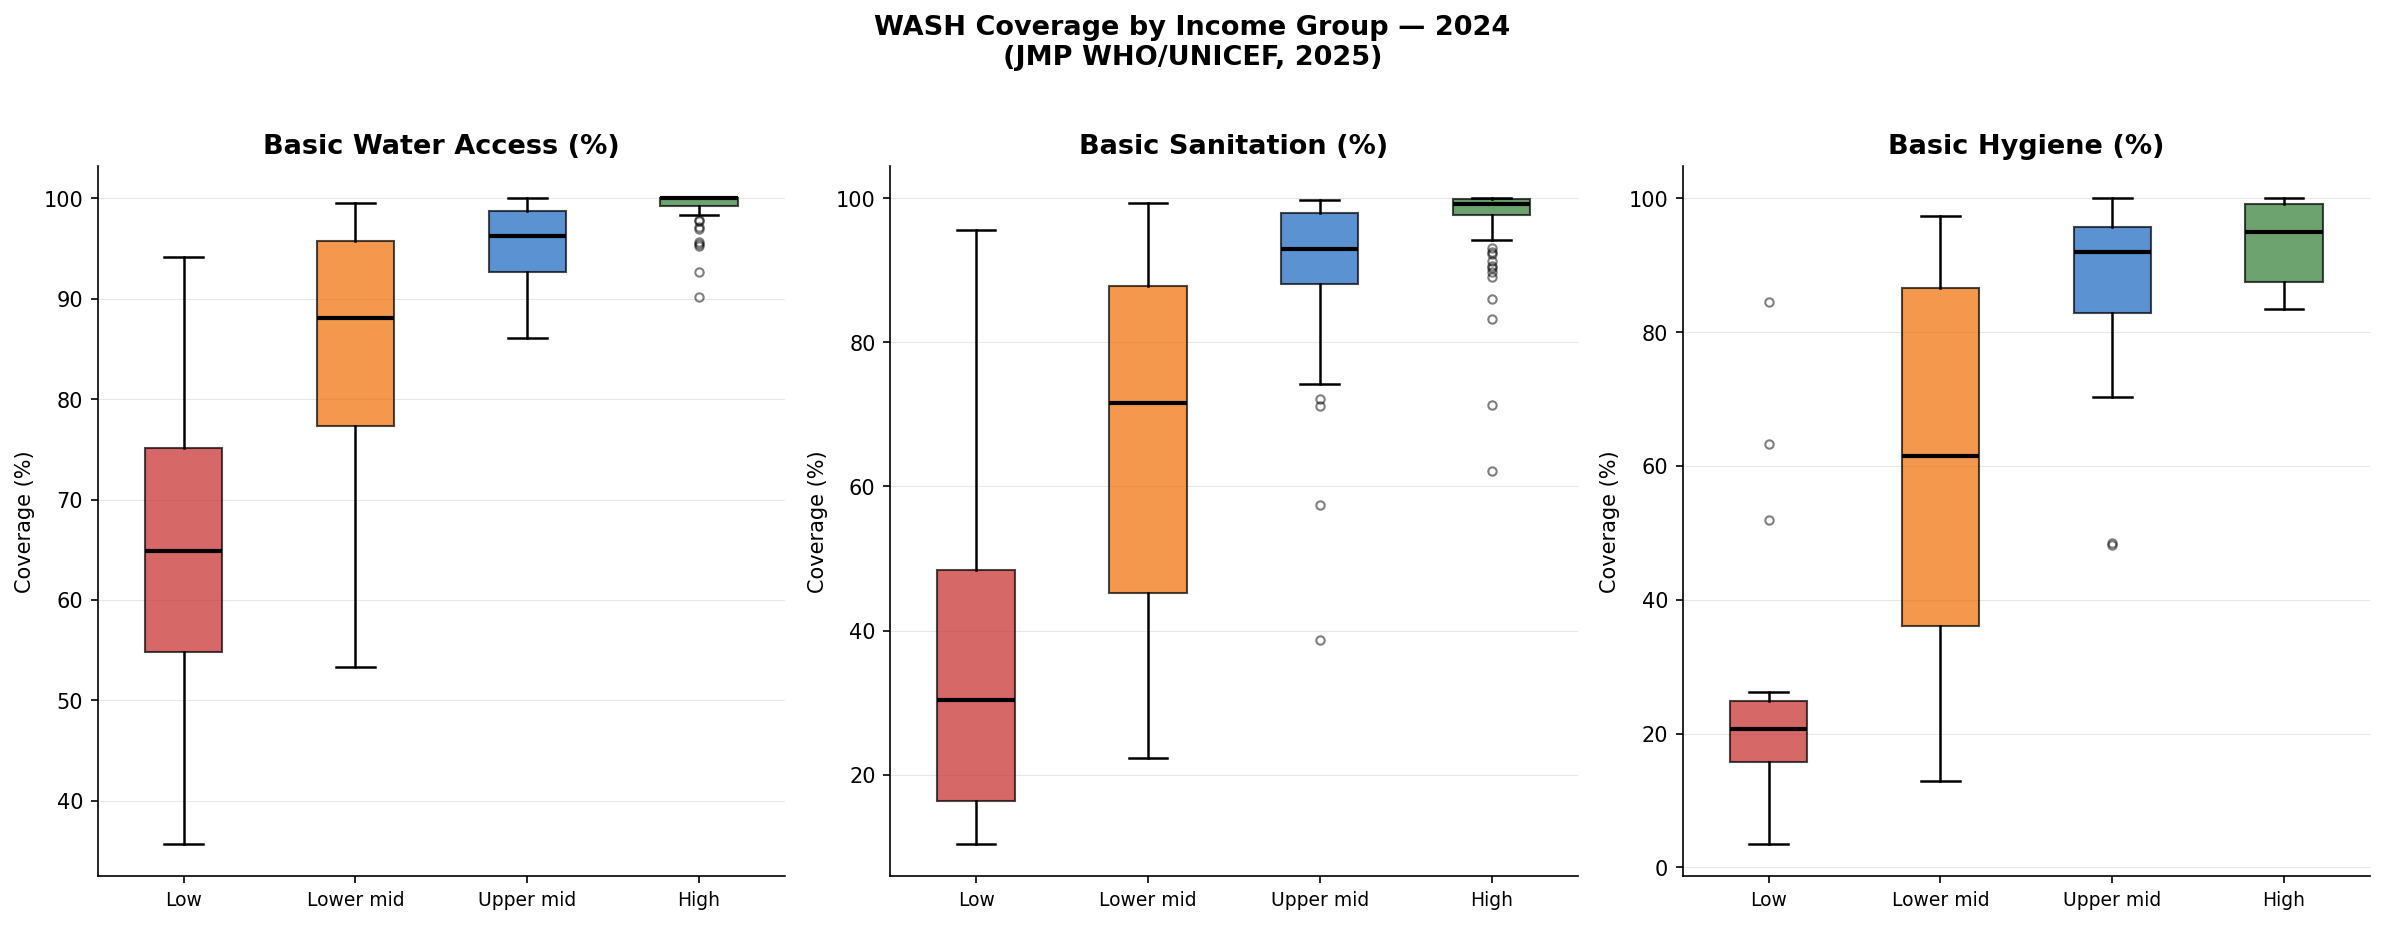

Saved: figures/fig3_income_comparison.png


In [7]:
# ── CELL 7: Figure 3 — Income group comparison ────────────────
income_order  = ['Low income','Lower middle income',
                 'Upper middle income','High income']
income_colors = ['#C62828','#EF6C00','#1565C0','#2E7D32']
income_labels = ['Low','Lower mid','Upper mid','High']

df2024_inc = df2024[df2024['region_income'].isin(income_order)].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('WASH Coverage by Income Group — 2024\n(JMP WHO/UNICEF, 2025)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (col, title) in zip(axes, [
    ('wat_basal_t', 'Basic Water Access (%)'),
    ('san_basal_t', 'Basic Sanitation (%)'),
    ('hyg_bas_t',   'Basic Hygiene (%)'),
]):
    groups = [df2024_inc[df2024_inc['region_income']==g][col].dropna()
              for g in income_order]

    bp = ax.boxplot(groups, patch_artist=True,
                    medianprops={'color':'black','linewidth':2},
                    whiskerprops={'linewidth':1.2},
                    capprops={'linewidth':1.2},
                    flierprops={'marker':'o','markersize':4,'alpha':0.5})

    for patch, c in zip(bp['boxes'], income_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)

    ax.set_xticklabels(income_labels, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Coverage (%)')
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig3_income_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig3_income_comparison.png")

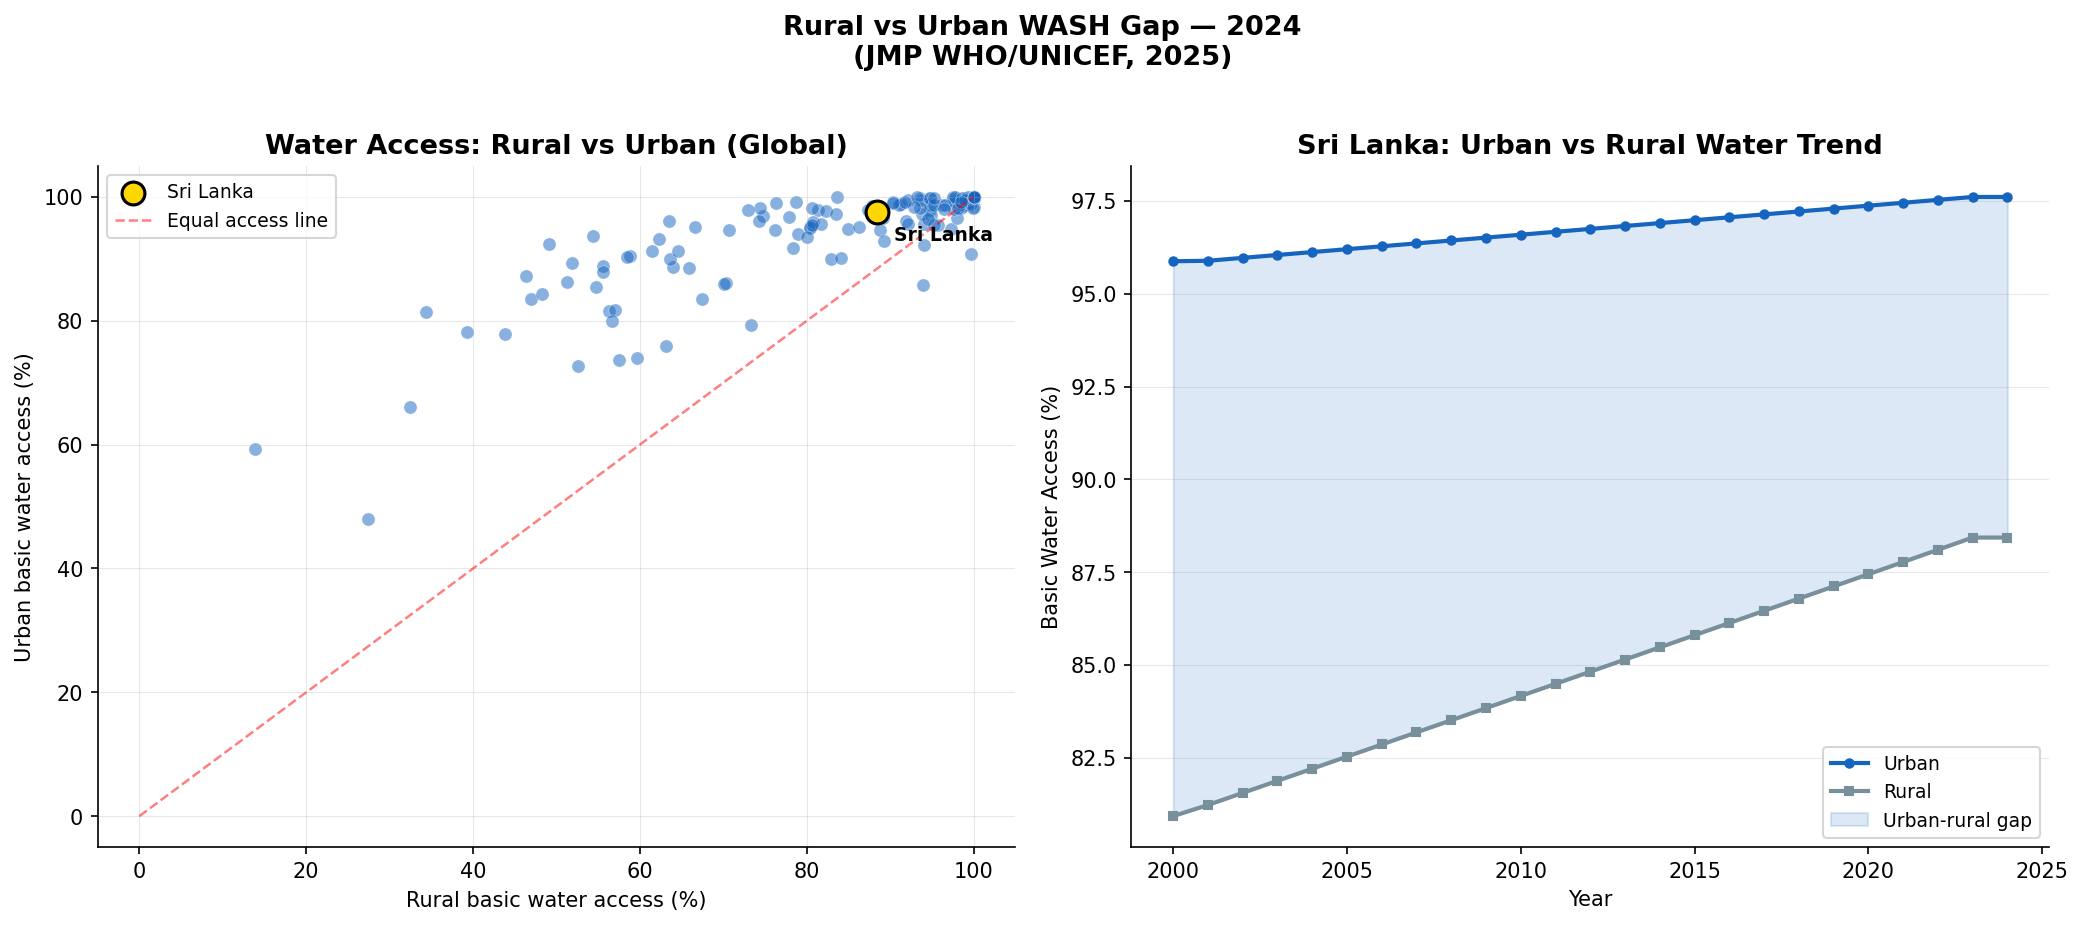

Saved: figures/fig4_rural_urban_gap.png


In [8]:
# ── CELL 8: Figure 4 — Rural vs Urban gap (Sri Lanka + Global) ─
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Rural vs Urban WASH Gap — 2024\n(JMP WHO/UNICEF, 2025)',
             fontsize=13, fontweight='bold', y=1.02)

# Panel A: Global scatter — urban vs rural water access
ax = axes[0]
valid = df2024.dropna(subset=['wat_basal_r','wat_basal_u'])
sc = ax.scatter(valid['wat_basal_r'], valid['wat_basal_u'],
                alpha=0.5, s=40, color='#1565C0', edgecolors='white', linewidths=0.3)

# Highlight Sri Lanka
sl24 = sl[sl['year']==2024]
ax.scatter(sl24['wat_basal_r'], sl24['wat_basal_u'],
           color='gold', s=120, zorder=5, edgecolors='black',
           linewidths=1.5, label='Sri Lanka')
ax.annotate('Sri Lanka', 
            (sl24['wat_basal_r'].values[0], sl24['wat_basal_u'].values[0]),
            xytext=(8, -14), textcoords='offset points', fontsize=9, fontweight='bold')

ax.plot([0,100],[0,100], 'r--', alpha=0.5, linewidth=1.2, label='Equal access line')
ax.set_xlabel('Rural basic water access (%)')
ax.set_ylabel('Urban basic water access (%)')
ax.set_title('Water Access: Rural vs Urban (Global)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linewidth=0.5)
ax.spines[['top','right']].set_visible(False)

# Panel B: Sri Lanka rural-urban gap over time
ax = axes[1]
sl_ru = sl.dropna(subset=['wat_basal_r','wat_basal_u']).sort_values('year')
ax.plot(sl_ru['year'], sl_ru['wat_basal_u'], 'o-', color='#1565C0',
        linewidth=2, markersize=4, label='Urban')
ax.plot(sl_ru['year'], sl_ru['wat_basal_r'], 's-', color='#78909C',
        linewidth=2, markersize=4, label='Rural')
ax.fill_between(sl_ru['year'], sl_ru['wat_basal_r'], sl_ru['wat_basal_u'],
                alpha=0.15, color='#1565C0', label='Urban-rural gap')
ax.set_xlabel('Year')
ax.set_ylabel('Basic Water Access (%)')
ax.set_title('Sri Lanka: Urban vs Rural Water Trend', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig4_rural_urban_gap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig4_rural_urban_gap.png")

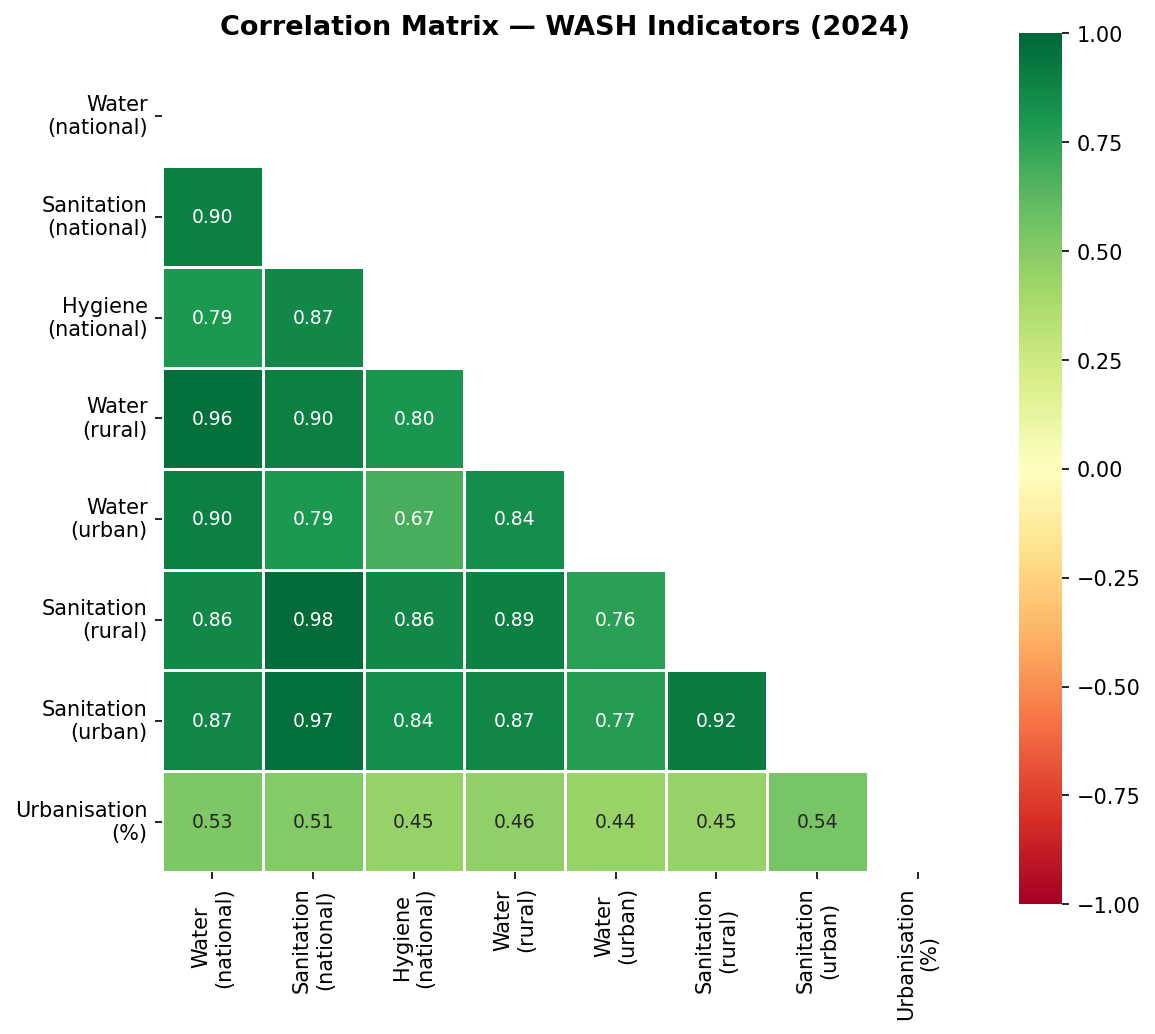

Saved: figures/fig5_correlation_heatmap.png


In [9]:
# ── CELL 9: Figure 5 — Correlation heatmap ────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

corr_cols = ['wat_basal_t','san_basal_t','hyg_bas_t',
             'wat_basal_r','wat_basal_u',
             'san_basal_r','san_basal_u',
             'prop_u']

corr_labels = ['Water\n(national)','Sanitation\n(national)','Hygiene\n(national)',
               'Water\n(rural)','Water\n(urban)',
               'Sanitation\n(rural)','Sanitation\n(urban)',
               'Urbanisation\n(%)']

corr = df2024[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, square=True, linewidths=0.5,
            xticklabels=corr_labels, yticklabels=corr_labels,
            vmin=-1, vmax=1, center=0, ax=ax,
            annot_kws={'size': 9})

ax.set_title('Correlation Matrix — WASH Indicators (2024)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../figures/fig5_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig5_correlation_heatmap.png")

In [10]:
# ── CELL 10: Save datasets for next notebooks ──────────────────
import os
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

df.to_csv('../outputs/master_dataset.csv', index=False)
df2024.to_csv('../outputs/dataset_2024.csv', index=False)
sl.to_csv('../outputs/srilanka_data.csv', index=False)

print("Saved to outputs/:")
print(f"  master_dataset.csv  — {len(df):,} rows (all countries, all years)")
print(f"  dataset_2024.csv    — {len(df2024):,} rows (latest snapshot)")
print(f"  srilanka_data.csv   — {len(sl):,} rows (25-year Sri Lanka data)")
print()
print("Figures saved to figures/:")
for i in range(1,6):
    print(f"  fig{i}_*.png")
print()
print("Notebook 1 COMPLETE. Open 02_mpri_clustering.ipynb next.")

Saved to outputs/:
  master_dataset.csv  — 5,594 rows (all countries, all years)
  dataset_2024.csv    — 211 rows (latest snapshot)
  srilanka_data.csv   — 25 rows (25-year Sri Lanka data)

Figures saved to figures/:
  fig1_*.png
  fig2_*.png
  fig3_*.png
  fig4_*.png
  fig5_*.png

Notebook 1 COMPLETE. Open 02_mpri_clustering.ipynb next.
